# Camera → BEV segmentation — training

Stage 1: surround cameras → BEV drivable-area + vehicle segmentation, metric BEV mIoU.

This notebook's first block is **data loading**: build the train/val datasets over
nuScenes keyframes, each carrying the 6 camera images, raw per-sensor calibration,
and the precomputed BEV raster target. It stops at the `DataLoader` boundary — the
`collate_fn` (variable per-sample sensor/agent batching + masking) and the
`DataLoader` setup are written separately.

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch

REPO_ROOT = Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from bev.data import CAMERAS, NuScenesBEVDataset, NuScenesConfig, Sample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch {torch.__version__}  device={device}")

torch 2.9.1+cu129  device=cuda


In [2]:
# Paths and grid/target configuration.
DATAROOT = REPO_ROOT / "data" / "nuscenes"
VERSION = "v1.0-mini"
RASTER_ROOT = REPO_ROOT / "data" / "bev_rasters"

# Stage 1 is camera-only: all 6 cameras in, lidar off. The BEV target comes from
# the precomputed raster store, so annotations are not loaded at train time.
SPLITS = {"train": "mini_train", "val": "mini_val"}

In [3]:
def build_dataset(split: str) -> NuScenesBEVDataset:
    return NuScenesBEVDataset(
        NuScenesConfig(
            dataroot=DATAROOT,
            version=VERSION,
            split=split,
            cameras=CAMERAS,
            load_lidar=False,
            load_annotations=False,
            bev_raster_root=RASTER_ROOT / split,
        )
    )


train_set = build_dataset(SPLITS["train"])
val_set = build_dataset(SPLITS["val"])
print(f"train: {len(train_set)} keyframes   val: {len(val_set)} keyframes")

train: 323 keyframes   val: 81 keyframes


## Sanity check one sample

Confirm each item carries what the model and loss expect: 6 camera tensors, raw
calibration per camera, and a `(C, H, W)` BEV raster whose layers and grid match
the store. The per-layer occupied fraction is a quick read on the BEV class
imbalance the loss has to handle.

In [4]:
sample: Sample = train_set[0]

print(f"sample_token: {sample.sample_token}")
print(f"scene:        {sample.scene_name}")
print(f"cameras:      {list(sample.cameras)}")

cam = sample.cameras[CAMERAS[0]]
print(f"\n{cam.channel}: image {tuple(cam.image.shape)} {cam.image.dtype}")
print(f"  intrinsic:\n{cam.calib.intrinsic}")
print(f"  sensor2ego t: {cam.calib.sensor2ego_translation.tolist()}")
print(f"  ego2global t: {cam.calib.ego2global_translation.tolist()}")

raster = sample.bev_raster
assert raster is not None, "bev_raster_root not wired or sample missing a raster"
data = raster.data  # (C, H, W)
print(f"\nraster: {tuple(data.shape)} {data.dtype}  layers={raster.layer_names}")
print(f"  grid: {raster.spec.nx}x{raster.spec.ny} @ {raster.spec.resolution} m")
for c, name in enumerate(raster.layer_names):
    frac = float((data[c] > 0).float().mean())
    print(f"  {name:14s} occupied {frac:6.3%}")

sample_token: cd9964f8c3d34383b16e9c2997de1ed0
scene:        scene-0757
cameras:      ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT']

CAM_FRONT_LEFT: image (3, 900, 1600) torch.uint8
  intrinsic:
tensor([[1.2579e+03, 0.0000e+00, 8.2724e+02],
        [0.0000e+00, 1.2579e+03, 4.5092e+02],
        [0.0000e+00, 0.0000e+00, 1.0000e+00]], dtype=torch.float64)
  sensor2ego t: [1.5752559464, 0.500519383135, 1.50696032589]
  ego2global t: [334.7712219122368, 658.6383442168495, 0.0]

raster: (2, 200, 200) torch.float32  layers=('drivable_area', 'vehicle')
  grid: 200x200 @ 0.5 m
  drivable_area  occupied 19.905%
  vehicle        occupied 1.250%


## DataLoaders

In [5]:
from torch.utils.data import DataLoader

from bev.data import collate_fn

TRAIN_BATCH_SIZE = 2
VAL_BATCH_SIZE = 2


train_loader = DataLoader(train_set, batch_size=TRAIN_BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=VAL_BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [6]:
import matplotlib.pyplot as plt

# test loader
train_sample = next(iter(train_loader))
print(train_sample)

SampleBatch(camera_batch=CameraDataBatch(channels=('CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'), images=tensor([[[[[ 1.5760e-01,  1.4595e-01,  1.5420e-01,  ..., -8.4515e-01,
            -8.5976e-01, -8.4814e-01],
           [ 1.6406e-01,  1.5575e-01,  1.6351e-01,  ..., -8.0825e-01,
            -8.0522e-01, -7.9581e-01],
           [ 1.7473e-01,  1.6679e-01,  1.7454e-01,  ..., -7.9634e-01,
            -7.9600e-01, -8.0428e-01],
           ...,
           [-3.8166e-01, -3.6799e-01, -3.4746e-01,  ..., -3.0821e-01,
            -3.0585e-01, -2.9619e-01],
           [-4.3271e-01, -4.2149e-01, -3.8387e-01,  ..., -3.7468e-01,
            -3.9418e-01, -3.6179e-01],
           [-4.3968e-01, -4.2898e-01, -3.8830e-01,  ..., -3.8279e-01,
            -4.0937e-01, -3.7465e-01]],

          [[ 3.7811e-01,  3.6621e-01,  3.7464e-01,  ..., -8.2208e-01,
            -8.3703e-01, -8.2514e-01],
           [ 3.8472e-01,  3.7622e-01,  3.8416e-01,  ..., -7.843

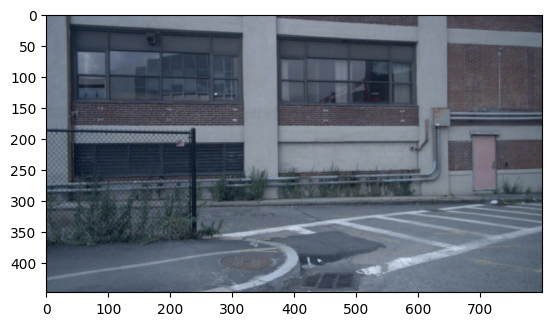

In [7]:
plt.imshow((train_sample.camera_batch.images[0,0].permute(1,2,0)-train_sample.camera_batch.images[0,0].min())/(train_sample.camera_batch.images[0,0].max()-train_sample.camera_batch.images[0,0].min()))

## Training

### ResNet inspection

In [8]:
# import torch
# from torch import nn

# from torchvision.models import (
#     resnet18,
#     resnet34,
#     resnet50,
#     ResNet18_Weights,
#     ResNet34_Weights,
#     ResNet50_Weights,
# )

In [9]:
# resnet = resnet18(weights=None)
# print(resnet)
# for name, child in resnet.named_children():
#     print(name, ":", child)
# for name, module in resnet.named_modules():
#     print(name, ":", module)
# for param_name, param_tensor in resnet.named_parameters():
#     print(param_name, ":", param_tensor.shape)
# for name, child in resnet.layer1[0].named_children():
#     print(name, ":", child)
# for name, parameter in resnet.layer1[0].conv1.named_parameters():
#     print(name, ":", parameter)
# print(resnet.layer1[0].conv1.weight.data)
# print(resnet.state_dict())
# print(ResNet18_Weights.IMAGENET1K_V1.transforms())

### Model creation & training

In [10]:
from bev.models import CameraBEVSeg

MIN_HEIGHT = -0.5
MAX_HEIGHT = 3.0
NUM_HEIGHTS = 4
MIN_DEPTH = 0
MAX_DEPTH = 42
NUM_DEPTHS = 42

import gc
# free any previous model/optimizer before rebuilding
for _name in ("camera_bev_seg", "opt"):
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()

camera_bev_seg = CameraBEVSeg(train_set[0].bev_raster.spec, train_set[0].bev_raster.layer_names, MIN_HEIGHT, MAX_HEIGHT, NUM_HEIGHTS, MIN_DEPTH, MAX_DEPTH, NUM_DEPTHS)

# if warm-start or just loading the model
# state = torch.load("models/camera_bev_seg_best.pt", map_location=device, weights_only=True)
# camera_bev_seg.load_state_dict(state)

camera_bev_seg.to(device)

/home/pliampas/PROJECTS/bev-perception/.venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


CameraBEVSeg(
  (bevlift): BEVLift(
    (backbone): ResNetBackbone(
      (resnet): ResNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
            (conv1): Conv2d(64, 64, kernel_size=(3, 3), str

In [ ]:
import gc
from bev.data.nuscenes_dataset import SampleBatch
from bev.models import SegLoss
from bev.viz.predictions import plot_bev_predictions

GAMMA = 2
ALPHAS = (0.25, 0.5)
EPS = 1e-5
LAMBDA = 1

seg_loss = SegLoss(GAMMA, ALPHAS, EPS, LAMBDA).to(device)

opt = torch.optim.Adam(camera_bev_seg.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=1e-12)

# fixed set of 5 val frames, sampled once, to watch the same frames improve
viz_batch = collate_fn([val_set[i] for i in range(5)])
viz_batch.to(device)

NUM_EPOCHS = 50
MAX_PATIENCE = 50

prev_total_loss = -1
patience_cnt = 0

# clear GPU before training (release remnants from prior runs)
gc.collect()
torch.cuda.empty_cache()

for epoch in range(NUM_EPOCHS):
    print(f"Starting epoch {epoch}")

    camera_bev_seg.train()

    total_train_loss = 0

    sample: SampleBatch
    for sample in train_loader:
        input = sample.camera_batch.to(device)
        target = sample.bev_raster_batch.data.to(device)
        opt.zero_grad()
        logits = camera_bev_seg(input)
        loss = seg_loss(logits, target)
        total_train_loss += loss.item()
        loss.backward()
        opt.step()
    
    print(f"Epoch {epoch} training loss: {total_train_loss}")
    
    camera_bev_seg.eval()
    total_val_loss = 0

    with torch.no_grad():
        for sample in val_loader:
            input = sample.camera_batch.to(device)
            target = sample.bev_raster_batch.data.to(device)
            logits = camera_bev_seg(input)
            loss = seg_loss(logits, target)
            total_val_loss += loss.item()
    
    print(f"Epoch {epoch} val loss: {total_val_loss}")

    del sample, input, target, logits, loss
    gc.collect()
    torch.cuda.empty_cache()

    plot_bev_predictions(
        camera_bev_seg, viz_batch.camera_batch, viz_batch.bev_raster_batch.data,
        viz_batch.bev_raster_batch.layer_names, n=5,
        save_path=f"viz/epoch_{epoch}.png", title=f"epoch {epoch}",
    )

    torch.save(camera_bev_seg.state_dict(), f"models/camera_bev_seg_{epoch}.pt")

    if prev_total_loss == -1 or total_val_loss < prev_total_loss:
        torch.save(camera_bev_seg.state_dict(), f"models/camera_bev_seg_best.pt")
        prev_total_loss = total_val_loss
    
    if total_val_loss < prev_total_loss:
        patience_cnt = 0
    else:
        patience_cnt += 1
    
    if patience_cnt >= MAX_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

Starting epoch 0
